# 0 Prepping Work

## 0.1 Prepping up work

In [32]:
import os
import pandas as pdß
import numpy as np
import pprint
import json
import cv2
import random

import pickle # Load refs and annotations
from typing import Any, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchmetrics


import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw


In [33]:
torch.cuda.is_available()

False

In [34]:
if torch.backends.mps.is_available():
    print("MPS backend is available.")
    device = torch.device('mps')
elif torch.cuda.is_available():
    print("CUDA backend is available.")
    device = torch.device('cuda')
else:
    print("Neither CUDA or MPS backend are available. Resorting to CPU")
    device = torch.device('cpu')

MPS backend is available.


In [35]:
device = torch.device('cpu')

In [36]:
device

device(type='cpu')

## 0.2 Utils

In [37]:
class colors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    ORANGE = '\033[33m'
    RESULT =  '\033[94m'
    WARNING = '\033[93m'
    DEBUGGING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

def now():
    return datetime.datetime.now().strftime("%H:%M:%S")

def error(buffer):
    print(now()+" ["+colors.BOLD+colors.FAIL+"ERROR"+colors.ENDC+"] " + buffer +"\n")

def warning(buffer):
    print(now()+" ["+colors.BOLD+colors.ORANGE+"WARNING"+colors.ENDC+"] " + buffer +"\n")

def debugging(buffer):
    print(now()+" ["+colors.BOLD+colors.DEBUGGING+"DEBUG"+colors.ENDC+"] " + buffer +"\n")

def info(buffer):
    print(now()+" ["+colors.BOLD+colors.OKGREEN+"INFO"+colors.ENDC+"] " + buffer +"\n")
     

In [38]:
### modelUtils.py ###

get_device_first_call=True
def get_device():
    global get_device_first_call
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    if get_device_first_call:
        #info("The current device is " + device)
        get_device_first_call=False
    return device

def save_model(model, epoch, optimizer, total_loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': total_loss,
        }, path+"/personal_model_"+str(epoch)+".pt")

def load_model(model, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    return model, epoch, loss

class TensorBoard():
    # This class allows to log in tensorboard
    def __init__(self, log_dir):
        rootdir = log_dir
        max=1
        for file in os.listdir(rootdir):
            d = os.path.join(rootdir, file)
            if os.path.isdir(d) and file.startswith("exp"):
                num = int(file.replace("exp",""))
                if num > max:
                    max = num
        log_dir = log_dir+"/exp"+str(max+1)
        self.writer = SummaryWriter(log_dir=log_dir)

    def log_values(self, step, loss, accuracy, prefix):
        self.writer.add_scalar(f"{prefix}/loss", loss, step)
        self.writer.add_scalar(f"{prefix}/accuracy", accuracy, step)

    def close(self):
        self.writer.close()

## 0.3 Data Augmentation

In [39]:
class DataAugmentation():
    # This class is used to perform tranformation in order to have augmented data

    def blur(img):
        # Gaussian Blur the image
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.GaussianBlur(kernel_size=5),
            transforms.ToTensor(),
        ])
        img = transform(img)
        return img

    def rotate(img):
        # Rotate the image
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomRotation(degrees=180),
            transforms.ToTensor(),
        ])
        img = transform(img)
        return img
    def grayscale(img):
        # Convert the image to grayscale
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
        ])
        img = transform(img)
        return img
    def colorrand(img):
        # Randomly change the color of the image
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ColorJitter(brightness=0.01*random.randrange(1,50), contrast=0.01*random.randrange(1,50), saturation=0.01*random.randrange(1,50), hue=0.01*random.randrange(1,50)),
            transforms.ToTensor(),
        ])
        img = transform(img)
        return img
    def random_crop(img):
        # Randomly crop the image
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomCrop((224,224)),
            transforms.ToTensor(),
        ])
        img = transform(img)
        return img

    def random_augmentation(img):
        # Randomly choose a transformation to be applied to the image
        n = random.randint(0, 5)
        if n == 0:
            return DataAugmentation.blur(img)
        elif n == 1:
            return DataAugmentation.rotate(img)
        elif n == 2:
            return DataAugmentation.grayscale(img)
        elif n == 3:
            return DataAugmentation.colorrand(img)
        else:
            return DataAugmentation.random_crop(img)

# 1 - Zero-Shot Try

## 1.1 Data Preparation

In [40]:
_, preprocess = clip.load("RN50")

In [41]:
with open("./refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("./refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

## 1.2 Dataset

In [42]:
def getcaption(elem):
    li = []
    for e in elem["sentences"]:
        li.append(e['raw'])
    return li

In [43]:
class RefCOCOG(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name': 
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x 
                - y
                - width 
                - height
        }
    """
    def __init__(self, refs, annotations, split="train"):

        dataset = list()

        for elem in [d for d in refs if d["split"]==split]:
            file_name = os.path.join("./refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            sentences = elem['sentences']
            raws = []
            for i in sentences:
                raws.append(i['raw'])
            bbox = annotations[elem['ann_id']]
            for i in raws:
                dataset.append({"file_name":file_name,"raw":i,"bbox":bbox})

        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


In [44]:
class RefCOCOGTok(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name': 
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x 
                - y
                - width 
                - height
        }
    """
    def __init__(self, refs, annotations, preprocess, tokenizer, augment_data, split="train"):

        dataset = list()

        self.preprocess = preprocess
        self.tokenizer = tokenizer

        for elem in [d for d in refs if d["split"]==split]:
            file_name = os.path.join("./refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            sentences = elem['sentences']
            raws = []
            for i in sentences:
                raws.append(i['raw'])
            bbox = annotations[elem['ann_id']]
            for i in raws:
                dataset.append({"file_name":file_name,"raw":i,"bbox":bbox})


    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


In [45]:
with open("./refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("./refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

In [46]:
def pad_image(image):
    """
    Performs bottom-right padding of the original image to 640x640 (max size of images in the dataset).
    Bottom-right padding prevents corruption of bounding boxes.

    ### Arguments
    image: a PIL.Image to transform
    """
    padded_width, padded_height = 640, 640
    original_height, original_width = image.shape[:2]
    bottom_padding = padded_height - original_height
    right_padding = padded_width - original_width
    top_padding = 0
    left_padding = 0
    
    padded_image = cv2.copyMakeBorder(image, top_padding, bottom_padding, left_padding, right_padding, cv2.BORDER_CONSTANT, value=[0, 0, 0])

    return padded_image 

def collate_fn(batch):
    #print("Actual batch is made of : " + batch)
    images = []
    data = {}

    #Stores all images in a list
    for sample in batch:
        image = cv2.imread(sample["file_name"], 3)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = pad_image(image=image)

        y_ = image.shape[0]
        x_ = image.shape[1]


        images.append(transform(image))

        data['raw'] = sample['raw']
        x,y,z,c = sample['bbox'][0:4]
        y1=y 
        x1=x 
        y2=(y + z)
        x2=(x + c)

        image = cv2.resize(image,(224,224))
        targetSize = 224
        x_scale = targetSize / x_
        y_scale = targetSize / y_

        image = np.array(image)

        (origxT, origyT, origxB, origyB) = (x1, y1, x2, y2)
        x = int(np.round(origxT * x_scale))
        y = int(np.round(origyT * y_scale))
        xmax = int(np.round(origxB * x_scale))
        ymax = int(np.round(origyB * y_scale))
        data['bbox'] = [x,y,xmax,ymax]
        data['filename'] = sample["file_name"]
            
    images = torch.stack(images, dim=0)
    """
    for key in batch[0].keys():
        #if key != "file_name":
        #    data[key] = [sample[key] for sample in batch]
        data[key] = [sample[key] for sample in batch]
        if( key == 'bbox'):
            x,y,z,c = sample[key][0:4]
            y1=y 
            x1=x 
            y2=(y + z)
            x2=(x + c)
    """
    return images, data

transform = transforms.Compose([
    transforms.ToTensor(),
])

In [47]:
# create dataset and dataloader
dataset_test = RefCOCOG(refs, annotations, split="test")
dataset_valid = RefCOCOG(refs, annotations, split="train")
#print(dataset_valid[1]['file_name'])
print("---------------------------------------------------")
#plt.imshow(Image.open(dataset[2]["file_name"]))
dataloader_test = DataLoader(dataset_test, batch_size=1, collate_fn=collate_fn, num_workers=0)
dataloader_valid = DataLoader(dataset_test, batch_size=1, collate_fn=collate_fn, num_workers=0)


---------------------------------------------------


## 1.3 -Image Encoder

In [48]:
from ultralytics import YOLO

In [49]:
yolo_model = YOLO("yolov8n.pt")
yolo_model.to(device)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

## 1.4 - Text Encoder

In [50]:
model, preprocess = clip.load("RN50")
clip.tokenize(dataset_test[0]['raw'])

tensor([[49406,   518,   786,   530,  4481,  7356, 49407,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0]], dtype=torch.int32)

## 1.5 - IMG manipulation

In [51]:
def crop_image(image_path, bounding_box):
    # Load the image
    #print(image_path)
    image = Image.open(image_path).convert("RGB")

    # Extract the bounding box coordinates
    x_min, y_min, x_max, y_max = bounding_box
    # Crop the image using the bounding box coordinates
    cropped_image = image.crop((float(x_min), float(y_min), float(x_max), float(y_max)))
    # Convert the cropped image to a NumPy array
    cropped_array = np.array(cropped_image)

    return cropped_array

In [52]:
def cosine_similarity(images_z: torch.Tensor, texts_z: torch.Tensor):
  # normalise the image and the text
  images_z /= images_z.norm(dim=-1, keepdim=True)
  texts_z /= texts_z.norm(dim=-1, keepdim=True)

  # evaluate the cosine similarity between the sets of features
  similarity = (texts_z @ images_z.T)

  #return similarity.to(device)
  return similarity

In [53]:
#this function computes the IOU score between two bounding boxes
def compute_iou(bb1, bb2):
    #determining the coordinates of the intersection rectangle
    x_left = max(bb1[0], bb2[0])
    y_top = max(bb1[1], bb2[1])
    x_right = min(bb1[2], bb2[2])
    y_bottom = min(bb1[3], bb2[3])
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    #computing the area of both bboxes
    bb1_area = bb1[2] * bb1[3]
    bb2_area = bb2[2] * bb2[3]
    
    #computing iou
    iou = intersection_area / float(bb1_area + bb2_area - intersection_area)
    return iou

In [54]:
import torch.optim as optim

device = device
clip_model, preprocess = clip.load("RN50", device=device)
#clip_model.eval()
#text = clip.tokenize(q).to(device)
# Define optimizer
optimizer = optim.Adam(list(yolo_model.parameters()) + list(clip_model.parameters()), lr=1e-4)
samples = 0.0
cumulative_accuracy = 0.0
cumulative_iou = 0.0
visual_model = yolo_model.to(device)

        

In [56]:
def find_best_yolo_bbox8(sentence, net, vmodel, filename):
    results = vmodel(filename)       #yolo computes the bounding boxes of a given image
    boxes = results[0].boxes.data

    crops = []
    for bbox in boxes:
        x,y,x2,y2,_,_ = bbox
        crops.append([x,y,x2,y2])

    #goodcrops = cleancrops8(crops)  #fixing them to a usable format
    goodcrops = crops

    #tok_text = clip.tokenize(sentence).to(device)   #preparing the text
    tok_text = clip.tokenize(sentence)

    #best_sim = torch.tensor([[0.0]]).to(device)
    best_sim = torch.tensor([[0.0]])
    best_crop = None

    if len(goodcrops) == 0:
        return [0,0,0,0], 0
    else:
        for crop in goodcrops:
            cropped_image = crop_image(filename, crop)                  #clip computes the most similar cropped image 
            img = Image.fromarray(cropped_image)                  #to the given sentence
            img_tens = preprocess(img).unsqueeze(0)
            img_tens = img_tens.to(device)
            #img_tens = preprocess(img).unsqueeze(0)

            images_z = net.encode_image(img_tens).float()
            texts_z = net.encode_text(tok_text).float()

            temp_sim = cosine_similarity(images_z, texts_z)
            print(temp_sim)
            if temp_sim > best_sim:
                best_sim = temp_sim
                best_crop = crop

    return best_crop, best_sim      #returns the best bounding box and the similarity score


In [57]:
# Training loop
num_epochs = 2
for epoch in range(num_epochs):
    for _, data in dataloader_test:
        text = data['raw']
        bbox = data['bbox']
        file_name = data['filename']
        tok = clip.tokenize(text)

        best_bb, simil = find_best_yolo_bbox8(text, clip_model, visual_model,file_name)
        
        iouscore = compute_iou(best_bb,bbox)
        cumulative_iou += iouscore
        cumulative_accuracy += simil
        samples += 1
        
cumulative_accuracy = cumulative_accuracy / samples * 100
cumulative_iou = cumulative_iou / samples * 100


image 1/1 /Users/mattiacarolo/Documents/GitHub/DL2023-Carolo-Maines/refcocog/images/COCO_train2014_000000380440.jpg: 384x640 2 persons, 1 skis, 62.5ms
Speed: 1.2ms preprocess, 62.5ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
tensor([[0.1491]], grad_fn=<MmBackward0>)
tensor([[0.1866]], grad_fn=<MmBackward0>)
tensor([[0.1262]], grad_fn=<MmBackward0>)

image 1/1 /Users/mattiacarolo/Documents/GitHub/DL2023-Carolo-Maines/refcocog/images/COCO_train2014_000000380440.jpg: 384x640 2 persons, 1 skis, 58.3ms
Speed: 1.2ms preprocess, 58.3ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
tensor([[0.2357]], grad_fn=<MmBackward0>)
tensor([[0.2499]], grad_fn=<MmBackward0>)
tensor([[0.1886]], grad_fn=<MmBackward0>)

image 1/1 /Users/mattiacarolo/Documents/GitHub/DL2023-Carolo-Maines/refcocog/images/COCO_train2014_000000419645.jpg: 448x640 2 trucks, 64.8ms
Speed: 1.4ms preprocess, 64.8ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)
tensor([[0

KeyboardInterrupt: 

In [ ]:
boxes = []

for image, data in dataloader_test:
    image = image.to(device) # inutile
    text = data['filename']
    results = yolo_model(text)
    for r in results:
                im_array = r.plot()  # plot a BGR numpy array of predictions
                im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
                im.show()  # show image
    #print(results)
    print(text)
    print("--------------------------")
    boxes = results[0].boxes.data
    break

image 1/1 /Users/mattiacarolo/Documents/GitHub/DL2023-Carolo-Maines/refcocog/images/COCO_train2014_000000380440.jpg: 384x640 2 persons, 1 skis, 30.3ms
Speed: 3.3ms preprocess, 30.3ms inference, 4.8ms postprocess per image at shape (1, 3, 384, 640)
./refcocog/images/COCO_train2014_000000380440.jpg
--------------------------


In [ ]:
boxes

tensor([[230.8936,  40.7411, 371.0627, 306.3866,   0.9135,   0.0000],
        [375.0414,  68.9565, 510.8562, 262.2391,   0.8984,   0.0000],
        [243.1046, 261.4011, 381.8395, 339.3764,   0.6317,  30.0000]], device='mps:0')

In [ ]:
def var_bbox():
    test = dataset_test[0]

    for box in boxes:
        image = cv2.imread("./refcocog/images/COCO_train2014_000000380440.jpg", 3)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        x, y, x2, y2, _, _ = box
        cv2.rectangle(image, (int(x), int(y)), (int(x2), int(y2)), (255, 0, 0), 2)
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis('off')
        plt.show()

        targetSize = 224
        image = cv2.resize(image,(targetSize,targetSize))

        x = targetSize / x
        y = targetSize / y
        x2 = targetSize / x2
        y2 = targetSize / y2
        cv2.rectangle(image, (int(x), int(y)), (int(x2), int(y2)), (255, 255, 0), 2)
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis('off')
        plt.show()


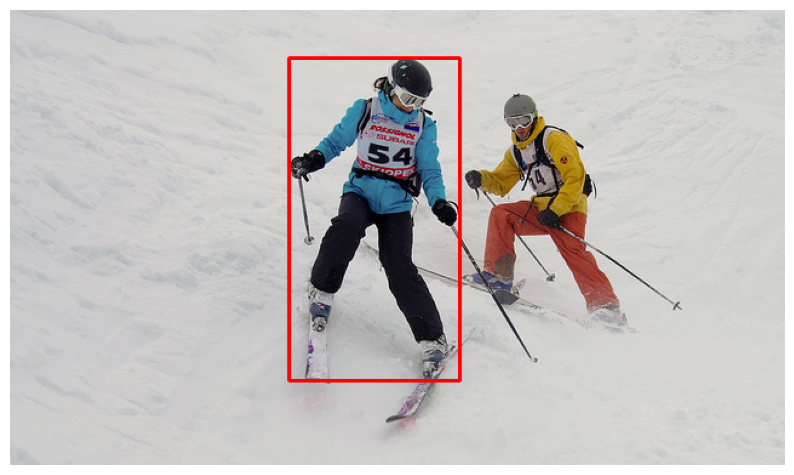

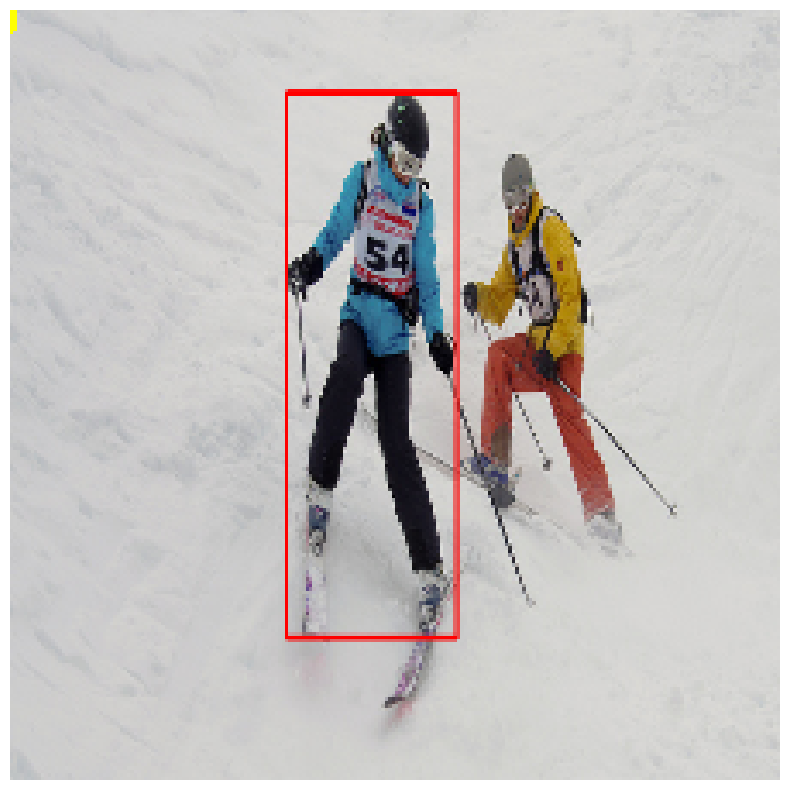

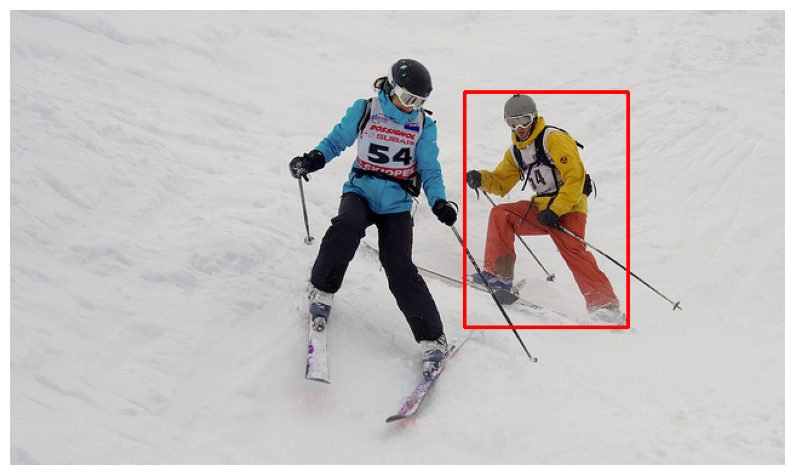

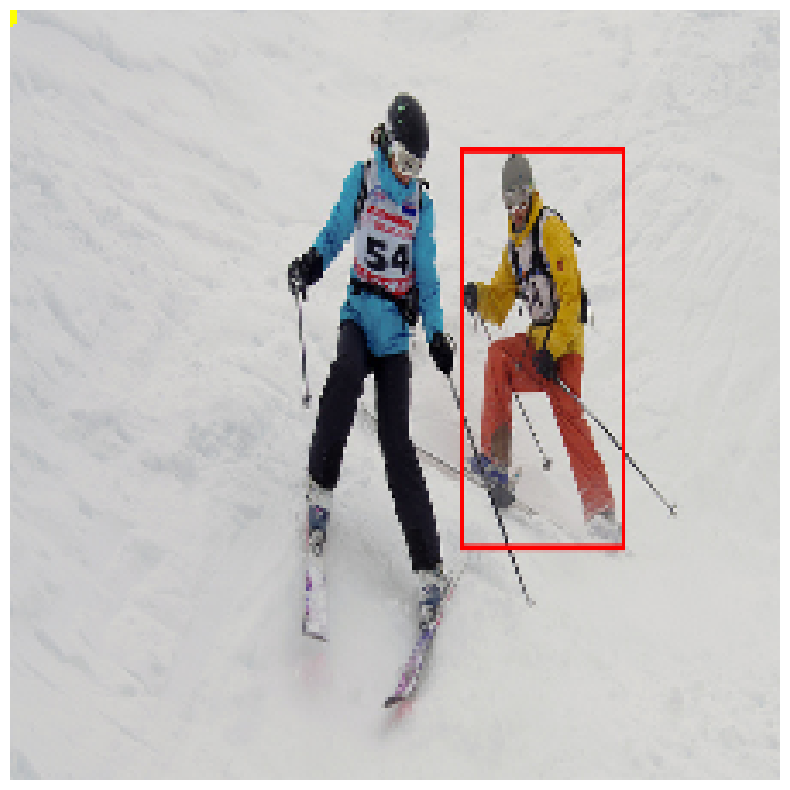

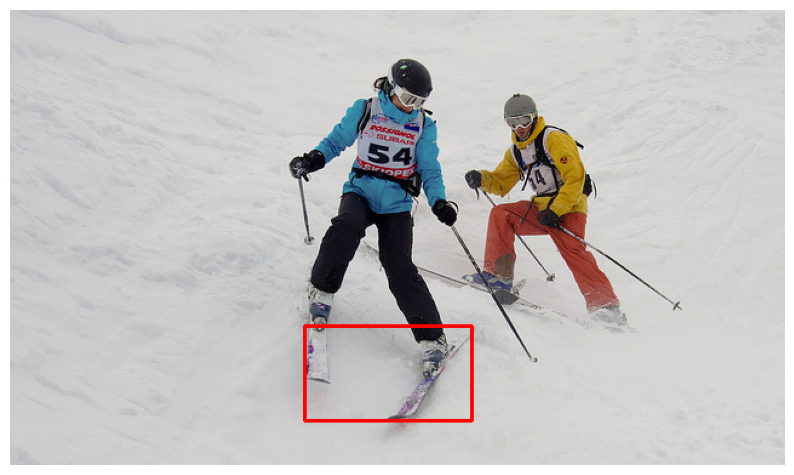

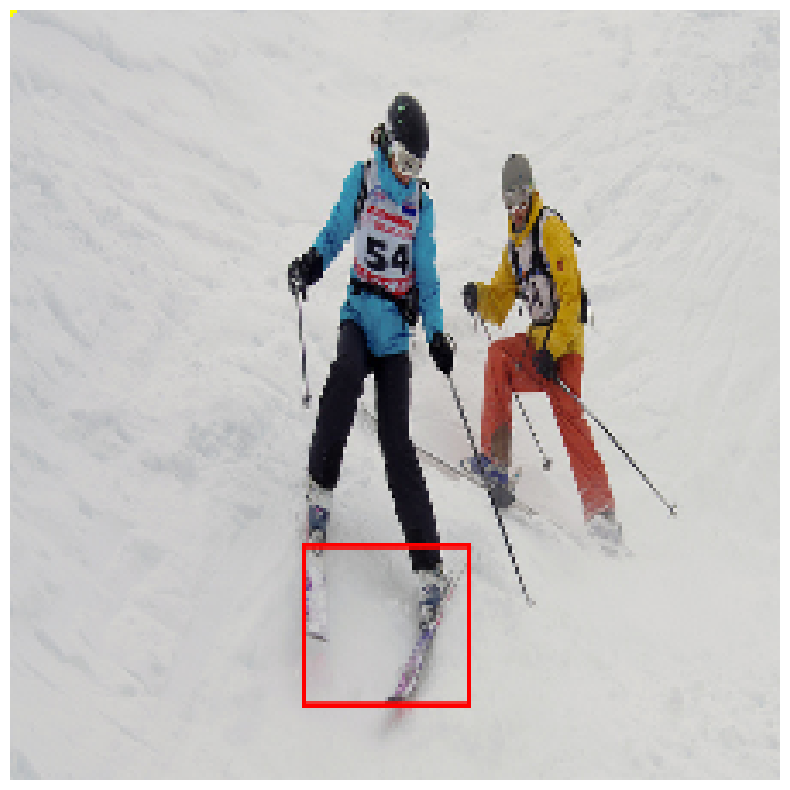

In [ ]:
var_bbox()

# 2 - Fine-Tune